# Dados e Aprendizagem Automática 26/27
### Part II

## **Decision Tree Classifier**

In [1]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import confusion_matrix
from sklearn.metrics import recall_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
from sklearn.metrics import f1_score
from sklearn.metrics import fbeta_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import root_mean_squared_error
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from sklearn.model_selection import cross_val_score

In [4]:
'''
Load CSV
'''

df = pd.read_csv("datasets/titanic_dataset.csv")


In [5]:
'''
Inspect dataset
'''
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

In [9]:
X = df.drop(['Survived'], axis=1)     
y = df['Survived'].to_frame()

NameError: name 'x' is not defined

,Survived
0,0
1,1
2,1
3,1
4,0
...,...
886,0
887,1
888,0
889,1


In [15]:
#Let's use the X and Y, which contain 891 rows of data
#to create train and test sets of data.
#Important -> Define the random_state for reproducibility
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=2021)


In [16]:
print("The shape of X %s. X_train has shape %s while X_test has shape %s" %(X.shape, X_train.shape, X_test.shape))

The shape of X (891, 11). X_train has shape (668, 11) while X_test has shape (223, 11)


In [17]:
print("The shape of y %s. y_train has shape %s while y_test has shape %s" %(y.shape, y_train.shape, y_test.shape))

The shape of y (891, 1). y_train has shape (668, 1) while y_test has shape (223, 1)


In [21]:
#Create an instance of a Decision Tree classifier
#Again, defining the random_state for reproducibility
clf = DecisionTreeClassifier(random_state=2021)

In [22]:
clf.fit(X_train, y_train)


ValueError: could not convert string to float: 'Ali, Mr. William'

In [25]:
#dropping categorical features from the input data (X_train and X_test)
X_train = X_train.drop(['Name', 'Sex', 'Age', 'Ticket', 'Cabin', 'Embarked'], axis=1)  
X_test = X_test.drop(['Name', 'Sex', 'Age', 'Ticket', 'Cabin', 'Embarked'], axis=1)    

In [26]:
#Training, i.e., fitting the model (using the training data!!)
clf.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",2021
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split among considered features for this split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: splitting may inspect more than ``max_features`` features ifneeded to find a valid split.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of sampl

In [28]:
#obtaining predictions
predictions = clf.predict(X_test)
predictions

array([0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0,
       0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1,
       0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1,
       0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1,
       1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       1, 1, 0])

In [29]:
print(y_test.values.shape)

(223, 1)


#### Quality Metrics and Model Evaluation

In [30]:
confusion_matrix(y_test, predictions)

array([[96, 39],
       [43, 45]])

In [31]:
accuracy_score(y_test, predictions)

0.6322869955156951

In [32]:
precision_score(y_test, predictions)

0.5357142857142857

In [33]:
recall_score(y_test, predictions)

0.5113636363636364

In [34]:
roc_auc_score(y_test, predictions)

0.6112373737373737

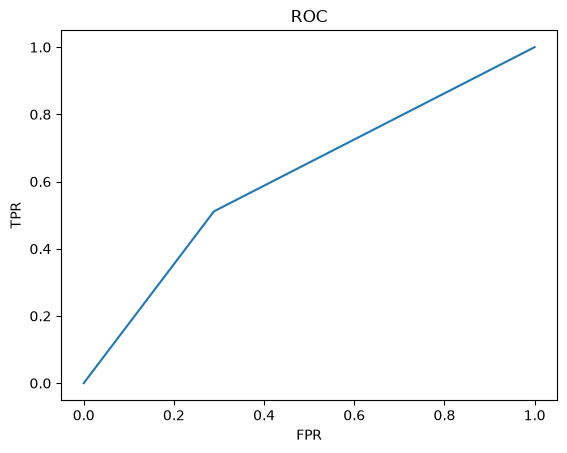

In [35]:
fpr, tpr, _ = roc_curve(y_test, predictions)

plt.clf()
plt.plot(fpr, tpr)
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('ROC')
plt.show()

In [36]:
f1_score(y_test, predictions)

0.5232558139534884

In [37]:
fbeta_score(y_test, predictions, beta=0.5)

0.5306603773584906

## **Decision Tree Regressor**

In [38]:
#Let's assume a REGRESSION problem! Let's predict the FARE paid by a person 
#(maybe not a very good problem but it serves its purpose)!
#Let's start by creating our X (input data) and our y (target feature - the Fare feature)
X = df.drop(['Fare'], axis=1)
y = df['Fare'].to_frame()

In [40]:
#Let's use the X and Y, which contain 891 rows of data
#to create train and test sets of data.
#Important -> Define the random_state for reproducibility
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=2021)

#dropping categorical features from the input data (X_train and X_test)
X_train = X_train.drop(['Name', 'Sex', 'Age', 'Ticket', 'Cabin', 'Embarked'], axis=1)  
X_test = X_test.drop(['Name', 'Sex', 'Age', 'Ticket', 'Cabin', 'Embarked'], axis=1 )    

In [42]:
#Create an instance of a Decision Tree regressor
#Again, defining the random_state for reproducibility
reg = DecisionTreeRegressor(random_state=2021)

In [43]:
#Training, i.e., fitting the model (using the training data!!)
reg.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",2021
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split among considered features for this split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: splitting may inspect more than ``max_features`` features ifneeded to find a valid split.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree wi

In [46]:
#obtaining predictions
predictions = reg.predict(X_test)
predictions

array([ 18.7875,   7.8958,  10.5   ,  27.9   ,  34.375 ,  24.15  ,
       211.5   ,   7.7417,  12.35  ,   7.2292,   7.2292,  52.    ,
        15.5   ,  18.7875,  13.    ,   8.6625,   8.05  ,  52.    ,
         8.6625,  35.5   ,  76.2917,  15.5   ,   7.6292,   8.4042,
         8.6625,   7.125 ,   7.775 ,   7.65  ,  93.5   ,  26.    ,
         7.8792,   8.6625,  39.6875,  16.1   , 113.275 ,  12.35  ,
         7.8958,   7.775 ,  29.7   ,  20.575 ,   7.8958,   7.75  ,
        33.5   ,   7.75  ,   7.8875,   8.1375,  69.55  ,   7.25  ,
        53.1   ,  13.    ,  78.2667,  27.75  ,  26.    ,  14.4542,
         7.25  ,  39.6875,  26.    ,   8.6625,  10.5   , 113.275 ,
        13.    ,  73.5   ,   7.05  ,  17.8   ,  59.4   ,  39.6875,
         8.05  ,  26.25  ,   7.25  ,   7.8958,  26.    ,  18.75  ,
         8.6625,   6.75  ,  46.9   ,  13.    , 113.275 ,   7.775 ,
        15.55  ,  11.2417,  27.    ,   7.2292,   0.    ,   7.225 ,
        69.55  ,   9.8375,  76.2917,  29.    ,  10.5   ,   7.8

#### Quality Metrics and Model Evaluation

In [47]:
mean_absolute_error(y_test, predictions)

14.68592556053812

In [48]:
mean_squared_error(y_test, predictions)

1399.7722041242152

In [49]:
root_mean_squared_error(y_test, predictions)

37.41352969347072

### Model Validation

#### **Cross_val_score**

In [51]:
'''
Load CSV
'''
df = pd.read_csv('datasets/titanic_dataset.csv')

In [52]:
#Let's start by creating our X (input data) and our y (target feature - the Survived feature)
X = df.drop(['Survived'], axis=1)
y = df['Survived'].to_frame()

In [53]:
print("USING A DECISION TREE WITH cross_val_score (MEAN ACCURACY)...")
X = X.drop(['Name', 'Sex', 'Age', 'Ticket', 'Cabin', 'Embarked'], axis=1)
clf = DecisionTreeClassifier(criterion='gini', max_depth=10, random_state=2021)
scores = cross_val_score(clf, X, y, cv=10)
print(scores)
print("RESULT: %0.2f accuracy with a standard deviation of %0.2f" % (scores.mean(), scores.std()))

USING A DECISION TREE WITH cross_val_score (MEAN ACCURACY)...
[0.58888889 0.61797753 0.52808989 0.50561798 0.61797753 0.70786517
 0.70786517 0.70786517 0.59550562 0.74157303]
RESULT: 0.63 accuracy with a standard deviation of 0.08


#### **K-fold**

In [ ]:
'''
Iterating manually (with K-fold, Repeated K-fold, Leave One Out, Shuffle Split, Stratified k-fold, TimeSeriesSplit, ...)
'''

from sklearn.model_selection import KFold

print("USING A DECISION TREE WITH MANUAL ITERATION (KFold) and obtaining confusion matrix...")

clf = DecisionTreeClassifier(criterion='gini', max_depth=10, random_state=2021)
scores = []
kf = KFold(n_splits=10, shuffle=True, random_state=2021)

for train, test in kf.split(X):
    X_train, X_test = X.iloc[train], X.iloc[test]
    y_train, y_test = y.iloc[train], y.iloc[test]
    
    clf.fit(X_train, y_train)
    
    score = clf.score(X_test, y_test)
    scores.append(score)
    
    y_predicted = clf.predict(X_test)
    
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_predicted))
    print(f"Fold Accuracy: {score:.2f}\n")

print("RESULT: %0.2f accuracy with a standard deviation of %0.2f" % (np.mean(scores), np.std(scores)))

USING A DECISION TREE WITH MANUAL ITERATION (KFold) and obtaining confusion matrix...
Confusion Matrix:
[[46 11]
 [17 16]]
Fold Accuracy: 0.69

Confusion Matrix:
[[40 11]
 [23 15]]
Fold Accuracy: 0.62

Confusion Matrix:
[[39 18]
 [16 16]]
Fold Accuracy: 0.62

Confusion Matrix:
[[42 10]
 [11 26]]
Fold Accuracy: 0.76

Confusion Matrix:
[[44 11]
 [21 13]]
Fold Accuracy: 0.64

Confusion Matrix:
[[43 11]
 [18 17]]
Fold Accuracy: 0.67

Confusion Matrix:
[[44 17]
 [15 13]]
Fold Accuracy: 0.64

Confusion Matrix:
[[42 15]
 [20 12]]
Fold Accuracy: 0.61

Confusion Matrix:
[[44 13]
 [16 16]]
Fold Accuracy: 0.67

Confusion Matrix:
[[34 14]
 [19 22]]
Fold Accuracy: 0.63

RESULT: 0.66 accuracy with a standard deviation of 0.04
